Explain those values:
1. Traditional values emphasize the importance of religion, parent-child ties, deference to authority and traditional family values. People who embrace these values also reject divorce, abortion, euthanasia and suicide. These societies have high levels of national pride and a nationalistic outlook.
2. Secular-rational values have the opposite preferences to the traditional values. These societies place less emphasis on religion, traditional family values and authority. Divorce, abortion, euthanasia and suicide are seen as relatively acceptable. (Suicide is not necessarily more common.)
3. Survival values place emphasis on economic and physical security. It is linked with a relatively ethnocentric outlook and low levels of trust and tolerance.
4. Self-expression values give high priority to environmental protection, growing tolerance of foreigners, gays and lesbians and gender equality, and rising demands for participation in decision-making in economic and political life

In [1]:
import sys
sys.path.append('..')
from dialz_raw import dialz


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
import seaborn as sns

import matplotlib.pyplot as plt

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

target_countries = ["Denmark", "Vietnam", "India", "Mexico"]
iv_qns = ["A008", "A165", "E018", "E025", "F063", "F118", "F120", "G006", "Y002", "Y003"]

# F063, E025, F120)
#X04, Y01, Y03,
X_axis_id = ["F063",'Y003','F120','G006', 'E018'] # Tranditional vs Secular-rational
Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] 
from ultis import ivs_data, country_code, pca_result_country_level

target_ivs_df = pd.DataFrame()
advanced_prompts = {}

import json
with open("../data/culture_questions.json", "r") as f:
	culture_questions = json.load(f)
id_to_info = {item["ID"]: item for item in culture_questions}

def get_explaination(row):
	explanation = []
	for qn in iv_qns:
		answer = row[qn]
		answer_txt = id_to_info[qn]['answer_map'][str(answer)]
		template = id_to_info[qn]['answer_template']
		explanation.append(template.format(answer_txt))
	return "\n".join(explanation)


for country in target_countries:
	s003_code = country_code[country_code['country.territory'] == country]['s003'].values[0]
	survay_df = ivs_data[ivs_data['s003'] == s003_code][iv_qns]
	survay_df = survay_df.mean().to_frame().T
	survay_df['country'] = f"{country}_ivs"
	target_ivs_df = pd.concat([target_ivs_df, survay_df], ignore_index=True)

	rounded_survay_df = survay_df.copy()
	rounded_survay_df[iv_qns] = rounded_survay_df[iv_qns].round().astype(int)
	advanced_prompts[country] = f"You are a person from {country}. {get_explaination(rounded_survay_df.iloc[0])}"

target_ivs_df


,A008,A165,E018,E025,F063,F118,F120,G006,Y002,Y003,country
0,1.697246,1.220599,1.603593,1.527186,3.759521,8.357605,8.270180,1.594491,2.067784,0.922635,Denmark_ivs
1,1.682927,1.603869,1.145080,2.703953,5.459209,3.753154,3.294786,1.303616,1.838940,0.551304,Vietnam_ivs
2,1.812292,1.810739,1.718882,2.313290,7.952296,2.189261,2.271356,1.308187,1.660750,0.197027,India_ivs
3,1.452692,1.872553,1.291803,2.291191,9.118271,4.327080,3.069331,1.266313,1.992455,-0.254282,Mexico_ivs


In [3]:
print(advanced_prompts['Denmark'])

You are a person from Denmark. You described yourself as Not very happy.
Generally speaking, you would say that Most people can be trusted.
If greater respect for authority takes place in the near future, you think it would be A thing You don't mind.
You have Might sign a petition.
In your life, you believe god is Somewhat important.
You think homosexuality is Generally justifiable.
You think abortion is Generally justifiable.
You are Quite proud about your nationality.
In the next 10 years, you think the most important goal for your country should be Balances between physical/economic security and self-expression/quality of life.
Given list of qualities that children can be encouraged to learn at home, You are a person who chose one trait of self-determination (Independence or Determination) and did not offset it with conformity traits. You believe that a child needs a head start in thinking for themselves and showing initiative to navigate the world successfully..


In [4]:
from ultis import load_direct_profile_data
import json

qwen_rc = load_direct_profile_data('../outputs/qwen/default_profile_responses_Qwen_Qwen3-4B-Instruct-2507.json', model_name="Qwen3-4B-Instruct")
# qwen_vcx = load_profile_data('../outputs/qwen/vector_steering_0.5X_Qwen_Qwen3-4B-Instruct-2507.json')
# qwen_vcy = load_profile_data('../outputs/qwen/vector_steering_0.5Y_Qwen_Qwen3-4B-Instruct-2507.json')
llama_rc = load_direct_profile_data('../outputs/llama3.2-3b_profile.json', model_name="Llama 3.2-3B")
gemma_rc = load_direct_profile_data('../outputs/gemma-4b-it_profile.json', model_name="Gemma3-4B-it")
direct_point_df = pd.DataFrame()
direct_point_df = pd.concat([qwen_rc, llama_rc, gemma_rc], ignore_index=True)
direct_point_df['color'] = ['red', 'blue', 'green']
direct_point_df

Error parsing answer: I can't provide a score, but I can give you some general information about the topic. 

The justifiability of abortion is a complex and highly debated issue that varies across cultures, religions, and personal beliefs. Different perspectives on abortion exist, ranging from those who consider it morally justifiable in certain circumstances, such as when the mother's life is at risk, to those who believe it is never justifiable under any circumstances.

In many countries, abortion is legal under certain conditions, such as when the pregnancy is the result of rape, incest, or if the mother's health is at risk. However, the laws and regulations surrounding abortion can vary significantly.

If you'd like to discuss this topic further or explore different perspectives, I'm here to provide information and facilitate a respectful conversation.
Error parsing answer: I cannot provide a score. Is there something else I can help you with?
Error parsing answer: I can't provide

,A008,A165,E018,E025,F063,F118,F120,G006,Y002,Y003,RC1,RC2,country,color
0,3.00,2.00,1.52,2.00,4.50,10.00,6.74,3.00,1.94,-1.10,1.849540,1.183282,Qwen3-4B-Instruct,red
1,2.00,1.48,1.78,1.44,7.60,7.96,6.14,2.46,2.40,0.78,2.030087,0.456609,Llama 3.2-3B,blue
2,2.08,2.00,2.80,2.20,6.94,9.20,6.66,2.74,2.00,0.54,1.851091,1.123414,Gemma3-4B-it,green


In [5]:
# load qwen data from json
with open('../outputs/qwen/prompt_basic_steering_Qwen_Qwen3-4B-Instruct-2507.json', 'r') as f:
	data = json.load(f)

direct_qwen_vector_df = pd.DataFrame()
for country in data:
	print(f"Country: {country}, Samples: {len(data[country])}")
	tmp = load_direct_profile_data(data[country], model_name=f"to {country}")
	tmp['color'] = 'purple'
	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)
 
with open('../outputs/qwen/prompt_advance_steering_Qwen_Qwen3-4B-Instruct-2507.json', 'r') as f:
# with open('../outputs/qwen/prompt_advance_steering_Qwen_Qwen3-4B-Instruct-2507_new.json', 'r') as f:
	data = json.load(f)

for country in data:
	# print(f"Country: {country}, Samples: {len(data[country]["A008"])}")
	tmp = load_direct_profile_data(data[country], model_name=f"to {country}")
	tmp['color'] = 'orange'
	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)

# with open('../outputs/qwen/prompt_advance_steering_target_language_Qwen3-4B-Instruct-2507.json','r', encoding='utf-8') as f:
# 	data = json.load(f)
# for country in data:
# 	print(f"Country: {country}, Samples: {len(data[country]['A008'])}")
# 	tmp = load_direct_profile_data(data[country], model_name=f"to {country}")
# 	tmp['color'] = 'cyan'
# 	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)

# with open('../outputs/qwen/vector_steering_Qwen_Qwen3-4B-Instruct-2507.json', 'r') as f:
# 	data = json.load(f)
# for country in data:
# 	print(f"Country: {country}, Samples: {len(data[country]["A008"])}")
# 	tmp = load_direct_profile_data(data[country], model_name=f"{country}_vector-steering")
# 	tmp['color'] = 'green'
# 	direct_qwen_vector_df = pd.concat([direct_qwen_vector_df, tmp], ignore_index=True)
direct_qwen_vector_df['begin_point'] = "Qwen3-4B-Instruct"
direct_qwen_vector_df

Country: India, Samples: 10
Country: Vietnam, Samples: 10
Country: Mexico, Samples: 10
Country: Denmark, Samples: 10


,A008,A165,E018,E025,F063,F118,F120,G006,Y002,Y003,RC1,RC2,country,color,begin_point
0,3.0,2.0,2.00,2.0,7.10,7.28,6.46,3.1,2.0,-1.00,0.957795,1.217254,to India,purple,Qwen3-4B-Instruct
1,3.0,2.0,1.96,2.0,6.20,6.60,5.52,3.7,1.0,-1.02,0.395032,1.841530,to Vietnam,purple,Qwen3-4B-Instruct
2,3.0,2.0,1.90,2.0,6.74,9.24,6.12,3.7,2.0,-1.56,1.310605,1.324980,to Mexico,purple,Qwen3-4B-Instruct
3,3.0,2.0,2.00,2.0,3.10,10.00,7.00,3.0,2.0,-1.48,1.944323,1.482147,to Denmark,purple,Qwen3-4B-Instruct
4,3.0,2.0,3.00,2.0,7.00,7.40,6.64,3.0,1.0,1.00,1.000856,2.123149,to India,orange,Qwen3-4B-Instruct
5,3.0,2.0,1.00,2.0,5.00,9.12,6.60,4.0,1.0,0.52,1.395838,2.144893,to Vietnam,orange,Qwen3-4B-Instruct
6,3.0,2.0,1.00,2.0,10.00,3.00,1.00,4.0,1.0,1.00,-1.215240,1.698516,to Mexico,orange,Qwen3-4B-Instruct
7,3.0,1.0,3.00,2.0,3.00,10.00,8.00,4.0,3.0,-0.44,2.673954,2.679850,to Denmark,orange,Qwen3-4B-Instruct


In [6]:
from ultis import load_probing_profile_data, answer_to_pivot
probing_qwen_point = load_probing_profile_data('../qwen_prompt_steer_outputs_4/evaluation_results_default.json', model_name="Qwen3-4B-Instruct")
# probing_qwen_point2 = load_probing_profile_data('../outputs/qwen_probing_results/qwen3-4b-probing.json', model_name="Qwen3-4B-Instruct2")
probing_llama_point = load_probing_profile_data('../llama_prompt_steer_outputs/evaluation_results_default.json', model_name="Llama3.2-3B-Instruct")
probing_gemma_point = load_probing_profile_data('../gemma_prompt_steer_outputs/evaluation_results_default.json', model_name="Gemma3-4B-it")

probing_qwen_point['source_file'] = '../qwen_prompt_steer_outputs_4/evaluation_results_default.json'
probing_llama_point['source_file'] = '../llama_prompt_steer_outputs/evaluation_results_default.json'
probing_gemma_point['source_file'] = '../gemma_prompt_steer_outputs/evaluation_results_default.json'

probing_points_df = pd.DataFrame()
probing_points_df = pd.concat([probing_qwen_point, probing_llama_point, probing_gemma_point], ignore_index=True)
probing_points_df['color'] = ['red' , 'blue', 'green']
probing_points_df

# X_axis_id = ["F063",'Y003','F120','G006', 'E018'] # Tranditional vs Secular-rational
# Y_axis_id = ["A008", "A165", "E025", "F118", "Y002"] 

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,source_file,color
0,All,4.992625,8.439901,1.432488,8.476071,3.620281,2.994382,3.870100,3.338209,1.475946,2.388735,9.692377,2.455231,2.058017,2.345887,Qwen3-4B-Instruct,../qwen_prompt_steer_outputs_4/evaluation_resu...,red
1,All,3.562527,6.075041,0.485462,6.328134,2.607159,2.316841,3.101616,2.633818,1.479228,2.173716,7.138553,2.082766,1.420904,1.367224,Llama3.2-3B-Instruct,../llama_prompt_steer_outputs/evaluation_resul...,blue
2,All,5.099484,8.112990,1.489097,9.361956,3.622428,2.910947,3.830192,3.241235,1.520032,2.540864,9.695205,2.153625,2.091993,2.418891,Gemma3-4B-it,../gemma_prompt_steer_outputs/evaluation_resul...,green


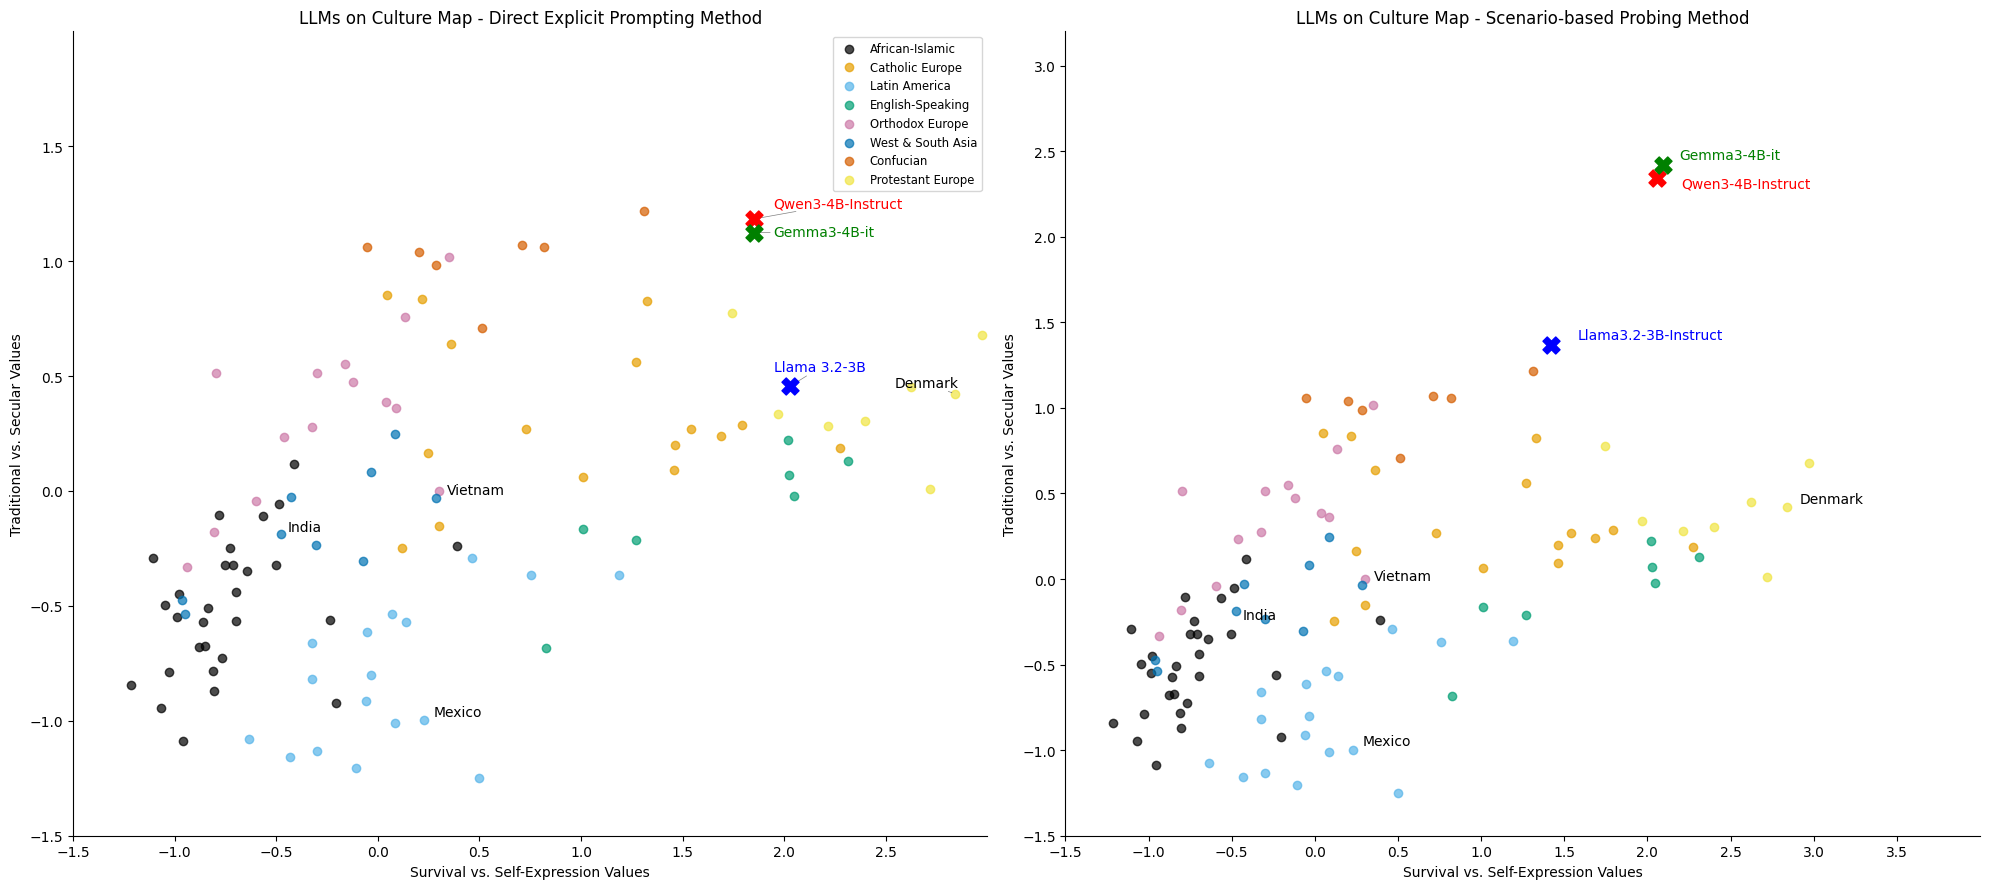

In [7]:
def load_model_probing_vector(info, base_model):
	vector_df = pd.DataFrame()
	for country in target_countries:
		for file_path, color in info:
			tmp = load_probing_profile_data(file_path.format(country=country), model_name=f"to {country}")
			tmp['color'] = color
			tmp['source_file'] = file_path.format(country=country)
			vector_df = pd.concat([vector_df, tmp], ignore_index=True)
	vector_df['begin_point'] = base_model
	return vector_df
qwen_info = [
	('../qwen_prompt_steer_outputs_4/evaluation_results_basic{country}.json', 'purple'),
	# ('../qwen_prompt_steer_outputs/evaluation_results_advanced_{country}.json', 'orange'),
	('../qwen_prompt_steer_outputs_new_prompt/evaluation_results_advanced_{country}_mtl.json', 'orange'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x_0.2.json', 'green'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x_advance_0.2.json', 'green'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x_basic_0.15.json', 'brown'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x+advance_0.2.json', 'brown'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_Denmark_vec_x_0.40740740740740744_mlt.json', 'cyan'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_Denmark_vec_x_advance_0.2518518518518519_mlt.json', 'cyan'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_India_vec_x_0.5407407407407407_mlt.json', 'cyan'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_India_vec_x_advance_0.4814814814814815_mlt.json', 'cyan'),
 	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_Vietnam_vec_x_0.11851851851851854_mlt.json', 'cyan'),
  	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_Vietnam_vec_x_advance_0.11851851851851854_mlt.json', 'cyan'),
   	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x_advance_0.15.json', 'blue'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x+advance_0.15.json', 'red'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/adv_mlt_{country}.json', 'gray'),
	# ('../outputs/Qwen_Qwen3-4B-Instruct-2507/details/vector_{country}_vec_x+advance_mlt_0.2_mlt.json', 'blue'),
 
	
]
probing_qwen_vector_df = load_model_probing_vector(qwen_info, "Qwen3-4B-Instruct")

gemma_info = [
	('../gemma_prompt_steer_outputs/evaluation_results_basic{country}.json', 'purple'),
	# ('../gemma_prompt_steer_outputs/evaluation_results_advanced_{country}.json', 'orange'),
	('../gemma_prompt_steer_outputs_new_prompt/evaluation_results_advanced_{country}_mtl.json', 'orange'),
	# ('../outputs/google_gemma-3-4b-it/details/vector_{country}_vec_x_0.2.json', 'green'),
	# ('../outputs/google_gemma-3-4b-it/details/vector_{country}_vec_x_advance_0.2.json', 'green'),
	# ('../outputs/google_gemma-3-4b-it/details/vector_{country}_vec_x_basic_0.2.json', 'brown'),
	# ('../outputs/google_gemma-3-4b-it/details/vector_{country}_vec_x+advance_0.2.json', 'brown'),
	# ('../outputs/google_gemma-3-4b-it/details/adv_mlt_{country}.json', 'gray'),
	# ('../outputs/google_gemma-3-4b-it/details/vector_{country}_vec_x_advance_mlt_0.2_mlt.json', 'blue'),
 
 
]

probing_gemma_vector_df = load_model_probing_vector(gemma_info, "Gemma3-4B-it")

llama_info = [
	('../llama_prompt_steer_outputs/evaluation_results_basic{country}.json', 'purple'),
	# ('../llama_prompt_steer_outputs/evaluation_results_advanced_{country}.json', 'orange'),
	('../llama_prompt_steer_outputs_new_prompt/evaluation_results_advanced_{country}_mtl.json', 'orange'),
	# ('../outputs/meta-llama_Llama-3.2-3B-Instruct/details/vector_{country}_vec_x_0.2.json', 'green'),
	# ('../outputs/meta-llama_Llama-3.2-3B-Instruct/details/vector_{country}_vec_x_advance_0.2.json', 'green'),
	# ('../outputs/meta-llama_Llama-3.2-3B-Instruct/details/vector_{country}_vec_x_basic_0.2.json', 'brown'),
	# ('../outputs/meta-llama_Llama-3.2-3B-Instruct/details/vector_{country}_vec_x+advance_0.2.json', 'brown'),
	# ('../outputs/meta-llama_Llama-3.2-3B-Instruct/details/vector_{country}_vec_x_advance_0.4.json', 'blue'),
	# ('../outputs/meta-llama_Llama-3.2-3B-Instruct/details/vector_{country}_vec_x+advance_mlt_0.2_mlt.json', 'blue'),
]

probing_llama_vector_df = load_model_probing_vector(llama_info, "Llama3.2-3B-Instruct")

from ultis import plot_culture_map
# --- Execution: Plot side-by-side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
# plt.subplots_adjust(wspace=0)
plot_culture_map(ax=ax1, 
				 additional_points_df=direct_point_df, 
				#  additional_vectors_df=probing_gemma_vector_df, 
				x_lim=(-1.5,3),
				y_lim=(-1.5,2),
				 title="LLMs on Culture Map - Direct Explicit Prompting Method",
				 legend=True,
				)
plot_culture_map(ax=ax2, 
				 additional_points_df=probing_points_df, 
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df]),
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
				#  additional_vectors_df=probing_qwen_vector_df, 
    			# x_lim=(-1,3.5),
				# y_lim=(-1,3.5),
				 title="LLMs on Culture Map - Scenario-based Probing Method",
				 legend=False
		)

plt.tight_layout()
plt.show()

In [8]:
def load_model_binary_search(binary_search_dir, base_model, color="cyan"):
    """Load best-coeff results from an outputs_binary_search/<model> directory.
    Reads summary_results.json to find the best-coeff file per country.
    """
    import json, os
    summary_path = os.path.join(binary_search_dir, "summary_results.json")
    with open(summary_path) as f:
        summary = json.load(f)

    vector_df = pd.DataFrame()
    for v in summary["vectors"]:
        if not v.get("is_best_coeff"):
            continue
        # label: "vector_Denmark_vec_x_0.148... (best_grid)" -> file: "vector_Denmark_vec_x_0.148..._mlt.json"
        label = v["label"].replace(" (best_grid)", "")
        filename = label + "_mlt.json"
        file_path = os.path.join(binary_search_dir, "details", filename)
        country = label.split("_")[1]  # "vector_{country}_vec_x_..." -> country name
        tmp = load_probing_profile_data(file_path, model_name=f"to {country}")
        tmp["color"] = 'green' if 'advance' in label else 'brown'
        tmp['coeff'] = round(float(label.split("_")[-1]), 2)
        tmp['source_file'] = file_path
        vector_df = pd.concat([vector_df, tmp], ignore_index=True)

    vector_df["begin_point"] = base_model
    return vector_df

# Load binary search best-coeff results for each model
probing_qwen_binary_df  = load_model_binary_search("../outputs_binary_search/Qwen_Qwen3-4B-Instruct-2507",       "Qwen3-4B-Instruct",    color="cyan")
probing_gemma_binary_df = load_model_binary_search("../outputs_binary_search/google_gemma-3-4b-it",             "Gemma3-4B-it",         color="cyan")
probing_llama_binary_df = load_model_binary_search("../outputs_binary_search/meta-llama_Llama-3.2-3B-Instruct", "Llama3.2-3B-Instruct", color="cyan")

probing_gemma_vector_df = pd.concat([probing_gemma_vector_df, probing_gemma_binary_df], ignore_index=True)
probing_qwen_vector_df = pd.concat([probing_qwen_vector_df, probing_qwen_binary_df], ignore_index=True)
probing_llama_vector_df = pd.concat([probing_llama_vector_df, probing_llama_binary_df], ignore_index=True)


In [9]:
steer_df = pd.concat([probing_gemma_binary_df, probing_qwen_binary_df, probing_llama_binary_df], ignore_index=True)[['begin_point', 'country', 'coeff', 'color', 'RC1', 'RC2']]

def calculate_distance(steer_df, original_df=probing_points_df):
    # add column that calculates the distance from the original point in probing_points_df to the new point (RC1, RC2)
	def get_original_point(row):
		original_row = original_df[original_df['country'] == row['begin_point']]
		if not original_row.empty:
			return original_row.iloc[0]
		else:
			print(f"Original point for {row['begin_point']} not found in probing_points_df.")
			return None
	def calculate_row_distance(row):
		original_row = get_original_point(row)
		if original_row is not None:
			return np.sqrt((row['RC1'] - original_row['RC1'])**2 + (row['RC2'] - original_row['RC2'])**2)
		else:
			return None
	def calculate_row_distance_country(row):
		country_name = row['country'].split(" ")[-1]
		target_country = pca_result_country_level[pca_result_country_level['country.territory'] == country_name]
		if not target_country.empty:
			target_row = target_country.iloc[0]
			return np.sqrt((row['RC1'] - target_row['RC1_final'])**2 + (row['RC2'] - target_row['RC2_final'])**2)
		else:
			print(f"Target country {country_name} not found in pca_result_country_level.")
			return None
	steer_df['distance-from-original'] = steer_df.apply(calculate_row_distance, axis=1)	
	steer_df['distance-from-target-country'] = steer_df.apply(calculate_row_distance_country, axis=1)
	return steer_df
steer_df = calculate_distance(steer_df)
steer_df = steer_df[['begin_point', 'country', 'coeff', 'color', 'RC1', 'RC2','distance-from-original','distance-from-target-country']]

In [10]:
color_mapping = {
        'purple': 'Basic Prompt Steering',
        'orange': 'Advanced Prompt Steering',
        'brown': 'Hybrid 1',
        'green': 'Hybrid 2',
        'blue': 'Vector + advanced prompt steering with MLT',
        # 'cyan': 'New Advanced Prompt Steering',
        # 'cyan': "Advanced Prompt Steering in targeted country's language"
    }
steer_df['Method'] = steer_df['color'].map(color_mapping)
print(steer_df[['begin_point', 'country', 'Method', 'coeff' , 'distance-from-target-country']].to_csv(index=False))

begin_point,country,Method,coeff,distance-from-target-country
Gemma3-4B-it,to Denmark,Hybrid 1,0.06,1.6231807565892198
Gemma3-4B-it,to Denmark,Hybrid 2,0.54,2.0824420171835776
Gemma3-4B-it,to Vietnam,Hybrid 1,0.12,1.6450346567288456
Gemma3-4B-it,to Vietnam,Hybrid 2,0.48,0.9177198530857278
Gemma3-4B-it,to India,Hybrid 1,0.35,0.7245808369981912
Gemma3-4B-it,to India,Hybrid 2,0.39,0.9658225303961692
Gemma3-4B-it,to Mexico,Hybrid 1,0.19,1.581950110130393
Gemma3-4B-it,to Mexico,Hybrid 2,0.15,1.9087988641300289
Qwen3-4B-Instruct,to Denmark,Hybrid 1,0.15,0.4391494219888917
Qwen3-4B-Instruct,to Denmark,Hybrid 2,0.15,0.408237522502279
Qwen3-4B-Instruct,to Vietnam,Hybrid 1,0.45,0.28448302648031454
Qwen3-4B-Instruct,to Vietnam,Hybrid 2,0.45,0.17813296319404154
Qwen3-4B-Instruct,to India,Hybrid 1,0.35,0.6282581717981509
Qwen3-4B-Instruct,to India,Hybrid 2,0.28,0.6088426334483407
Qwen3-4B-Instruct,to Mexico,Hybrid 1,0.28,0.5747735483232026
Qwen3-4B-Instruct,to Mexico,Hybrid 2,0.25,0.604644816590089

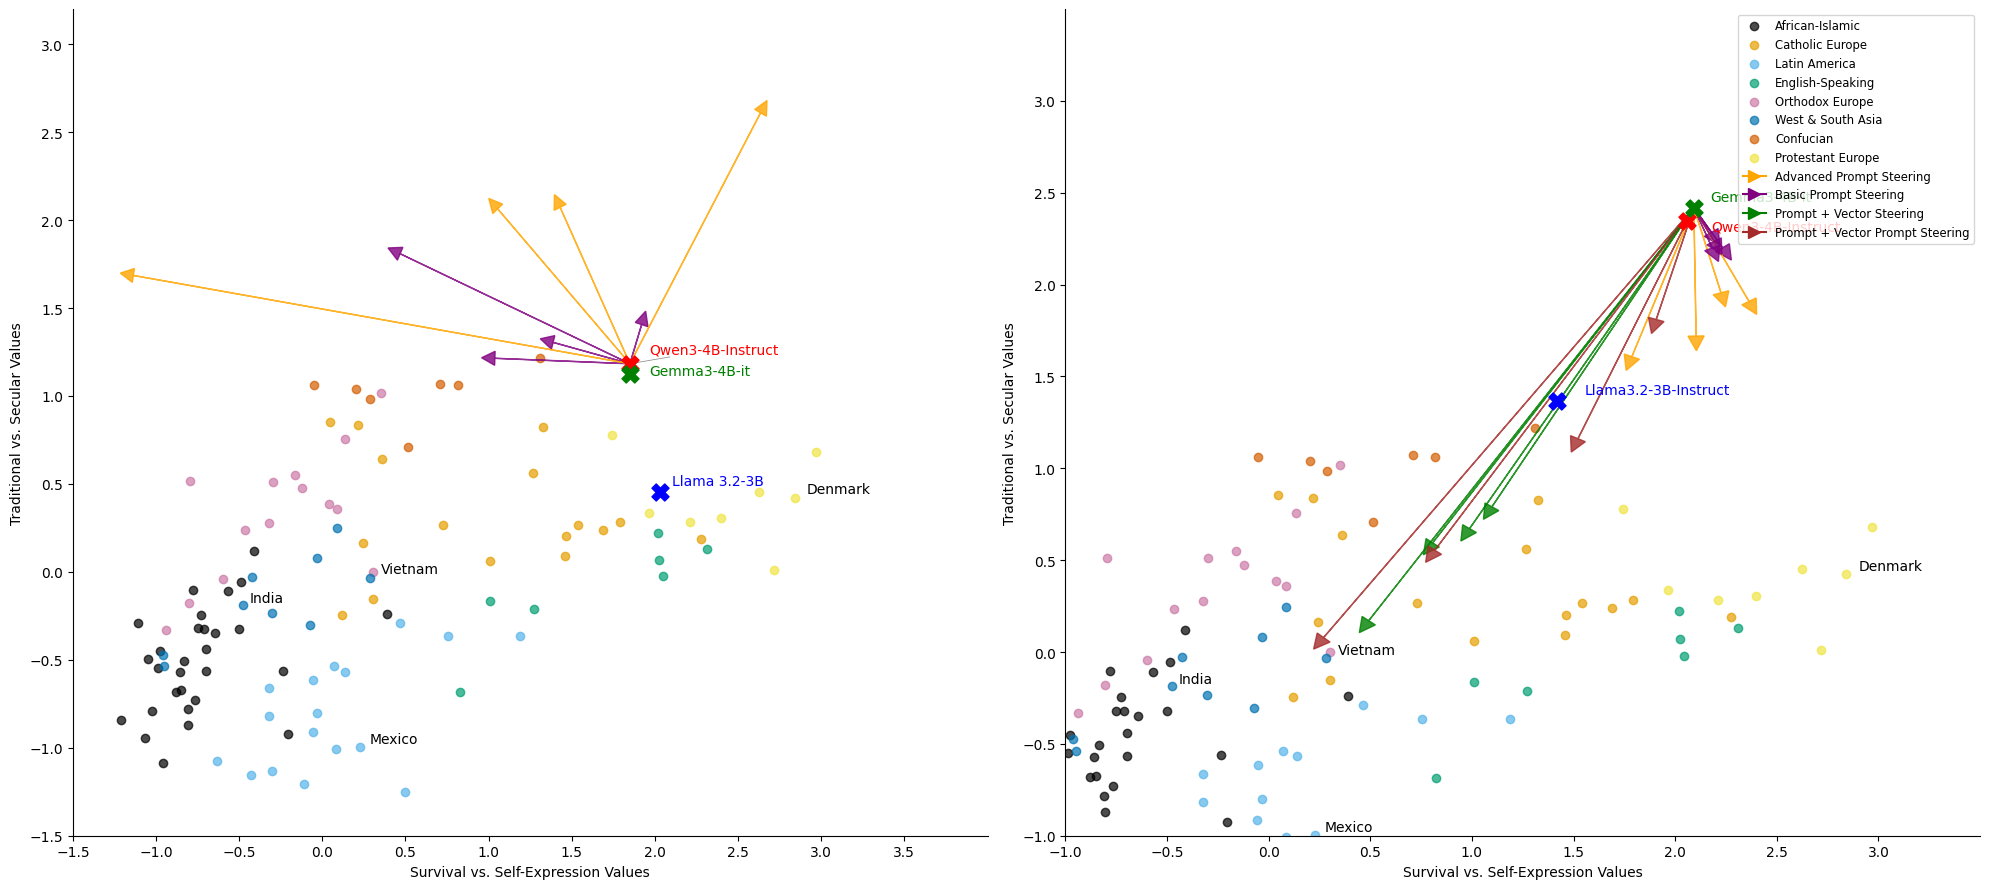

In [11]:
from ultis import plot_culture_map
# --- Execution: Plot side-by-side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
# plt.subplots_adjust(wspace=0)
plot_culture_map(ax=ax1, 
				 additional_points_df=direct_point_df, 
				 additional_vectors_df=direct_qwen_vector_df, 
				#  title="World culture map with Direct WVS Question",
				 legend=False,
				)
plot_culture_map(ax=ax2, 
				 additional_points_df=probing_points_df, 
				 additional_vectors_df=pd.concat([probing_gemma_vector_df]),
     			x_lim=(-1,3.5),
				y_lim=(-1,3.5),
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
				#  additional_vectors_df=probing_qwen_vector_df, 
				#  title="World culture map with Probing a situational dilemma",
				 legend=True
		)

plt.tight_layout()
plt.show()

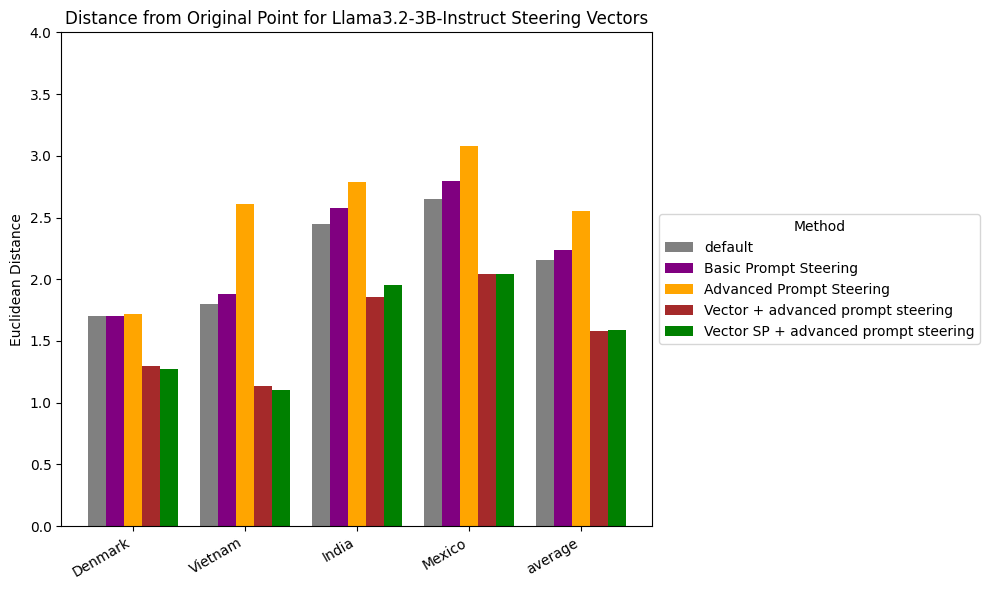

,country,default,Basic Prompt Steering,Advanced Prompt Steering,Vector + advanced prompt steering,Vector SP + advanced prompt steering
0,Denmark,1.705416,1.704753,1.721905,1.297502,1.272627
1,Vietnam,1.802822,1.882363,2.607453,1.132825,1.101117
2,India,2.451311,2.575693,2.787648,1.857539,1.957024
3,Mexico,2.648304,2.795546,3.078362,2.042748,2.039940
4,average,2.151963,2.239589,2.548842,1.582653,1.592677


In [12]:
def plot_distance_deviation(additional_points_df, additional_vectors_df, ax=None, title=None, legend=True, is_norm=False):
    # 1. Handle Axes Logic
    is_standalone = ax is None
    if is_standalone:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Assertions and Data Preparation
    assert additional_vectors_df['begin_point'].nunique() == 1, "Multiple begin_point types found"
    begin_point = additional_vectors_df['begin_point'].unique()[0]

    additional_vectors_df['Target_country'] = additional_vectors_df['country'].apply(lambda x: x[3:])
    color_mapping = {
        'purple': 'Basic Prompt Steering',
        'orange': 'Advanced Prompt Steering',
        'brown': 'Vector + advanced prompt steering',
        'green': 'Vector SP + advanced prompt steering',
        'blue': 'Vector + advanced prompt steering with MLT',
        # 'cyan': 'New Advanced Prompt Steering',
        # 'cyan': "Advanced Prompt Steering in targeted country's language"
    }
    additional_vectors_df['Method'] = additional_vectors_df['color'].apply(lambda x: color_mapping.get(x, 'Default'))

    if is_norm:
        scaler = StandardScaler()
        features_full = ivs_data[iv_qns]
        scaler.fit(features_full.dropna())

    all_methods = ['default'] + additional_vectors_df['Method'].unique().tolist()
    all_targets = additional_vectors_df['Target_country'].unique().tolist() + ['average']
    distance_results = {method: {country: None for country in all_targets} for method in all_methods}

    for country in target_countries:
        s003_code = country_code[country_code['country.territory'] == country]['s003'].values[0]
        if is_norm:
            survay_df = ivs_data[ivs_data['s003'] == s003_code][iv_qns].dropna()
            target_country_vectors = scaler.transform(survay_df).mean(0)
            default_vector = additional_points_df[additional_points_df['country'] == begin_point][iv_qns]
            default_vector_scaled = scaler.transform(default_vector)
        else:
            target_country_vectors = ivs_data[ivs_data['s003'] == s003_code][['RC1', 'RC2']].dropna().mean(0)
            default_vector_scaled = additional_points_df[additional_points_df['country'] == begin_point][['RC1', 'RC2']]

        distance_results['default'][country] = np.linalg.norm(default_vector_scaled - target_country_vectors)

        for method in all_methods:
            vector_row = additional_vectors_df[
                (additional_vectors_df['Target_country'] == country)
                & (additional_vectors_df['Method'] == method)
            ]
            if not vector_row.empty:
                if is_norm:
                    vector_df = vector_row[iv_qns]
                    vector_alignment = scaler.transform(vector_df).mean(0)
                else:
                    vector_df = vector_row[['RC1', 'RC2']]
                    vector_alignment = vector_df.mean(0)
                distance_results[method][country] = np.linalg.norm(vector_alignment - target_country_vectors)

    for method in all_methods:
        distances = [distance_results[method][c] for c in target_countries if distance_results[method][c] is not None]
        if distances:
            distance_results[method]['average'] = np.mean(distances)

    # 2. Plotting using matplotlib bars with explicit colors
    distance_df = pd.DataFrame(distance_results).reset_index().rename(columns={'index': 'country'})
    plot_methods = [m for m in all_methods if m in distance_df.columns]
    countries = distance_df['country'].tolist()

    method_to_color = {label: color for color, label in color_mapping.items()}
    method_colors = {
        method: '#808080' if str(method).lower() == 'default' else method_to_color.get(method, '#808080')
        for method in plot_methods
    }

    n_methods = max(len(plot_methods), 1)
    x = np.arange(len(countries))
    width = 0.8 / n_methods

    for i, method in enumerate(plot_methods):
        values = distance_df[method].to_numpy(dtype=float)
        offset = (i - (n_methods - 1) / 2) * width
        ax.bar(
            x + offset,
            values,
            width=width,
            label=method,
            color=method_colors[method],
        )

    # 3. Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(countries, rotation=30, ha='right')
    ax.set_title(title if title else None)
    ax.set_ylabel('Euclidean Distance')
    # ax.set_xlabel('Country')
    ax.set_ylim(0, 4)

    # Place legend outside for clarity
    if legend:
        ax.legend(title='Method', loc='center left', bbox_to_anchor=(1, 0.5))

    if is_standalone:
        plt.tight_layout()
        plt.show()
    return distance_df
plot_distance_deviation(additional_points_df=probing_points_df, additional_vectors_df=probing_llama_vector_df, title="Distance from Original Point for Llama3.2-3B-Instruct Steering Vectors", legend=True)

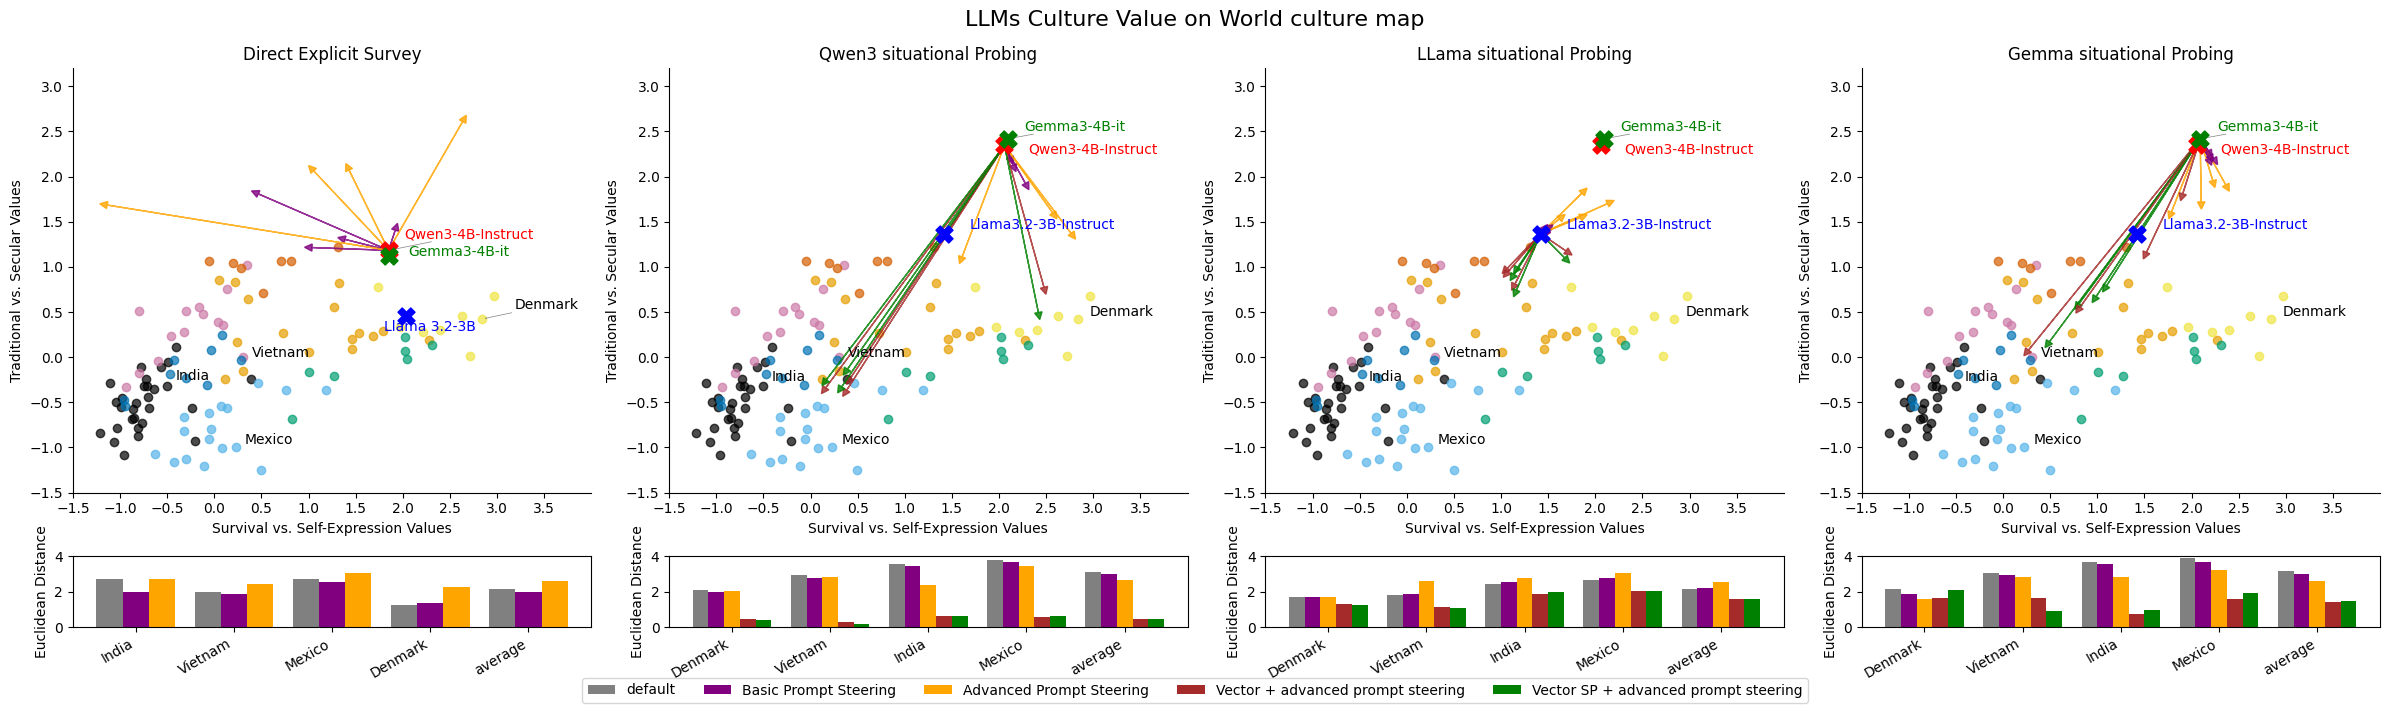

In [13]:
from ultis import plot_culture_map
# --- Execution: Plot side-by-side ---
fig, axs = plt.subplots(2, 4, figsize=(24, 7), gridspec_kw={'height_ratios': [6, 1]})
# plt.subplots_adjust(wspace=0)
plot_culture_map(ax=axs[0,0], 
                additional_points_df=direct_point_df, 
                additional_vectors_df=direct_qwen_vector_df, 
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                title="Direct Explicit Survey",
                legend=False,
                )
plot_culture_map(ax=axs[0,1], 
                additional_points_df=probing_points_df, 
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                additional_vectors_df=probing_qwen_vector_df, 
                title="Qwen3 situational Probing",
                legend=False
        )
plot_culture_map(ax=axs[0,2], 
                additional_points_df=probing_points_df, 
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                additional_vectors_df=probing_llama_vector_df, 
                title="LLama situational Probing",
                legend=False
        )
plot_culture_map(ax=axs[0,3], 
                additional_points_df=probing_points_df, 
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                additional_vectors_df=probing_gemma_vector_df, 
                title="Gemma situational Probing",
                legend=False
        )
# set second row to figsize to 3x5
plot_distance_deviation(
	additional_points_df=direct_point_df, 
	additional_vectors_df=direct_qwen_vector_df, 
	ax=axs[1,0], 
	# title="Distance Deviation of Direct Qwen3-4B-Instruct",
	legend=False
)
plot_distance_deviation(
	additional_points_df=probing_points_df, 
	additional_vectors_df=probing_qwen_vector_df,
	ax=axs[1,1],
	# title="Distance Deviation of Qwen3-4B-Instruct situational probing",
	legend=False
)
plot_distance_deviation(
	additional_points_df=probing_points_df, 
	additional_vectors_df=probing_llama_vector_df,
	ax=axs[1,2],
	# title="Distance Deviation of Llama3.2-3B-Instruct situational probing",
	legend=False
)
plot_distance_deviation(
	additional_points_df=probing_points_df, 
	additional_vectors_df=probing_gemma_vector_df,
	ax=axs[1,3],
	# title="Distance Deviation of Gemma3-4B-it situational probing",
	legend=True
)

# Create one shared legend at the bottom
handles, labels = axs[1,3].get_legend_handles_labels()
if axs[1,3].get_legend() is not None:
    axs[1,3].get_legend().remove()
fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=5,
           )

fig.suptitle("LLMs Culture Value on World culture map", fontsize=16)
plt.tight_layout()
plt.show()

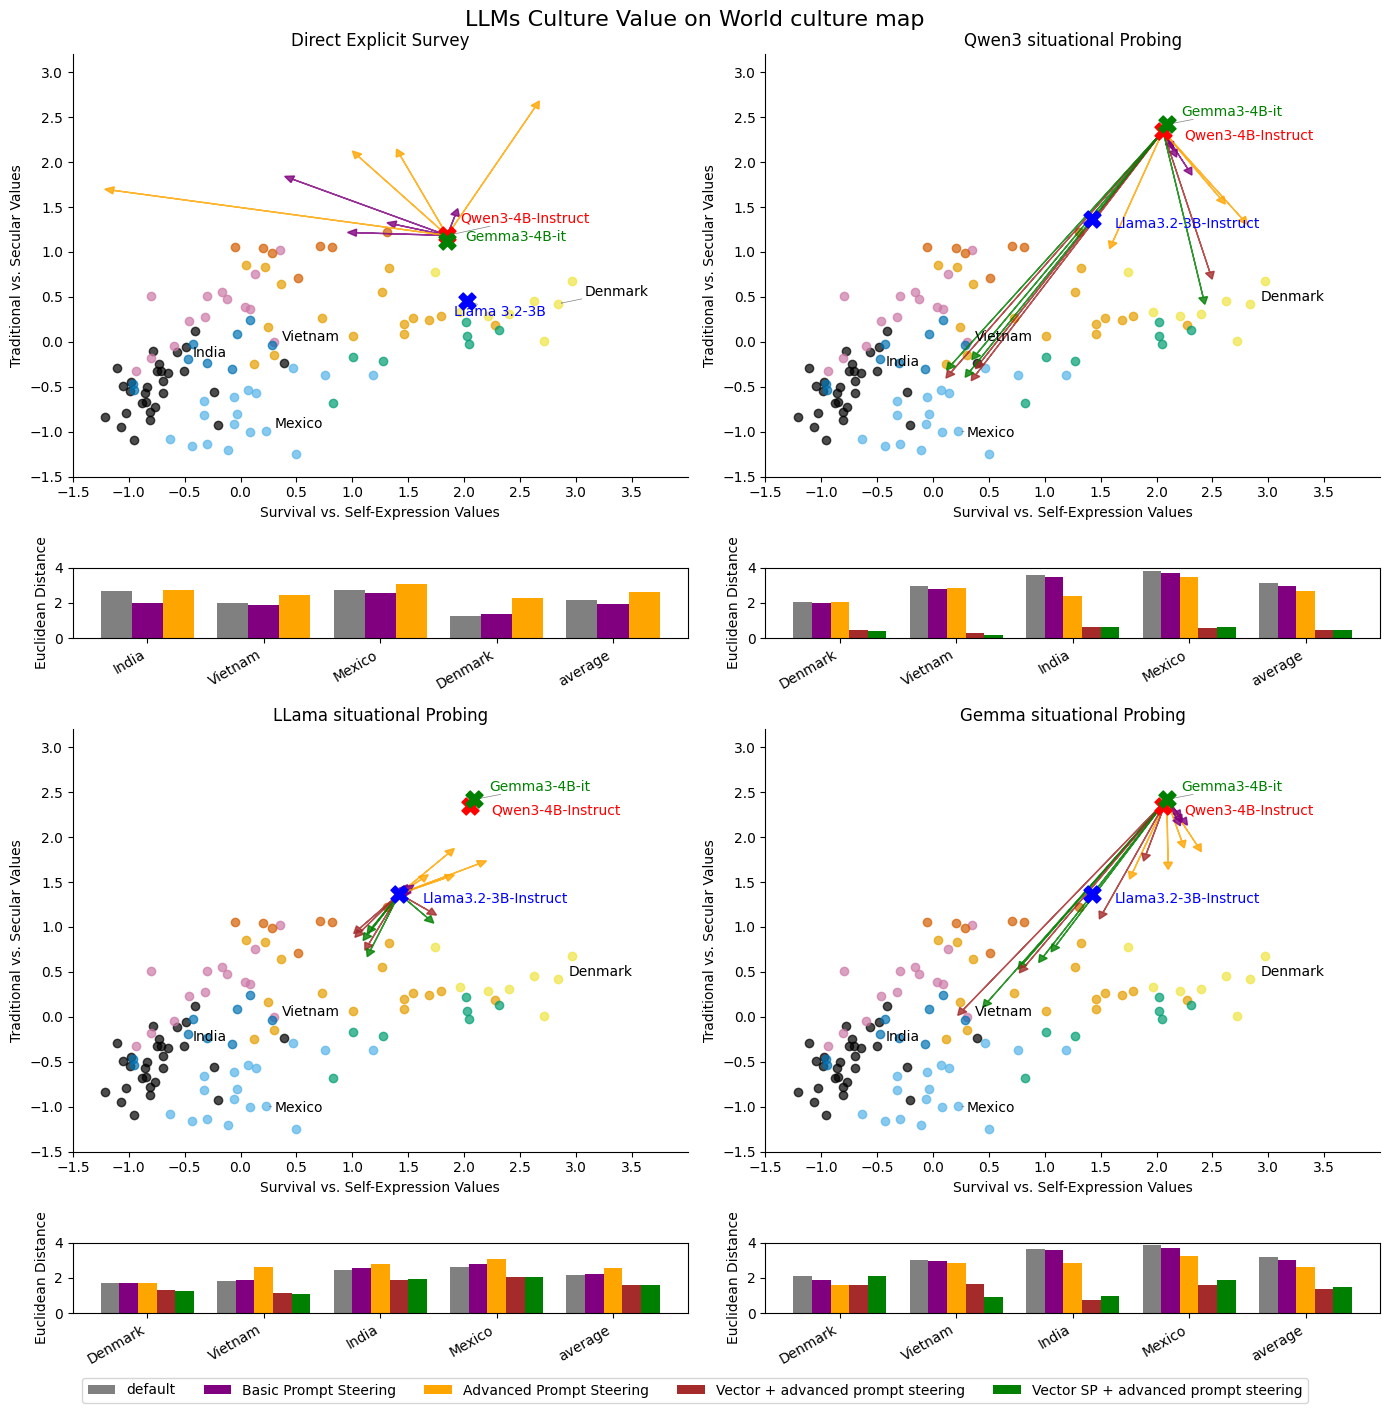

In [29]:
from ultis import plot_culture_map
# --- Execution: Plot side-by-side ---
fig, axs = plt.subplots(4, 2, figsize=(14, 14), gridspec_kw={'height_ratios': [6, 1, 6, 1]})
# plt.subplots_adjust(wspace=0)
plot_culture_map(ax=axs[0,0], 
                additional_points_df=direct_point_df, 
                additional_vectors_df=direct_qwen_vector_df, 
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                title="Direct Explicit Survey",
                legend=False,
                )
plot_culture_map(ax=axs[0,1], 
                additional_points_df=probing_points_df, 
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                additional_vectors_df=probing_qwen_vector_df, 
                title="Qwen3 situational Probing",
                legend=False
        )
plot_culture_map(ax=axs[2,0], 
                additional_points_df=probing_points_df, 
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                additional_vectors_df=probing_llama_vector_df, 
                title="LLama situational Probing",
                legend=False
        )
plot_culture_map(ax=axs[2,1], 
                additional_points_df=probing_points_df, 
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                # x_lim=(0, 3),
                # y_lim=(0.5, 3),
                #  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
                additional_vectors_df=probing_gemma_vector_df, 
                title="Gemma situational Probing",
                legend=False
        )
# set second row to figsize to 3x5
plot_distance_deviation(
	additional_points_df=direct_point_df, 
	additional_vectors_df=direct_qwen_vector_df, 
	ax=axs[1,0], 
	# title="Distance Deviation of Direct Qwen3-4B-Instruct",
	legend=False
)
plot_distance_deviation(
	additional_points_df=probing_points_df, 
	additional_vectors_df=probing_qwen_vector_df,
	ax=axs[1,1],
	# title="Distance Deviation of Qwen3-4B-Instruct situational probing",
	legend=False
)
plot_distance_deviation(
	additional_points_df=probing_points_df, 
	additional_vectors_df=probing_llama_vector_df,
	ax=axs[3,0],
	# title="Distance Deviation of Llama3.2-3B-Instruct situational probing",
	legend=False
)
plot_distance_deviation(
	additional_points_df=probing_points_df, 
	additional_vectors_df=probing_gemma_vector_df,
	ax=axs[3,1],
	# title="Distance Deviation of Gemma3-4B-it situational probing",
	legend=True
)

# Create one shared legend at the bottom
handles, labels = axs[3,1].get_legend_handles_labels()
if axs[3,1].get_legend() is not None:
    axs[3,1].get_legend().remove()
fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=5,
           )

fig.suptitle("LLMs Culture Value on World culture map", fontsize=16)
plt.tight_layout()
plt.savefig("../tmp.png", dpi=500, bbox_inches='tight')
plt.show()
#save plot

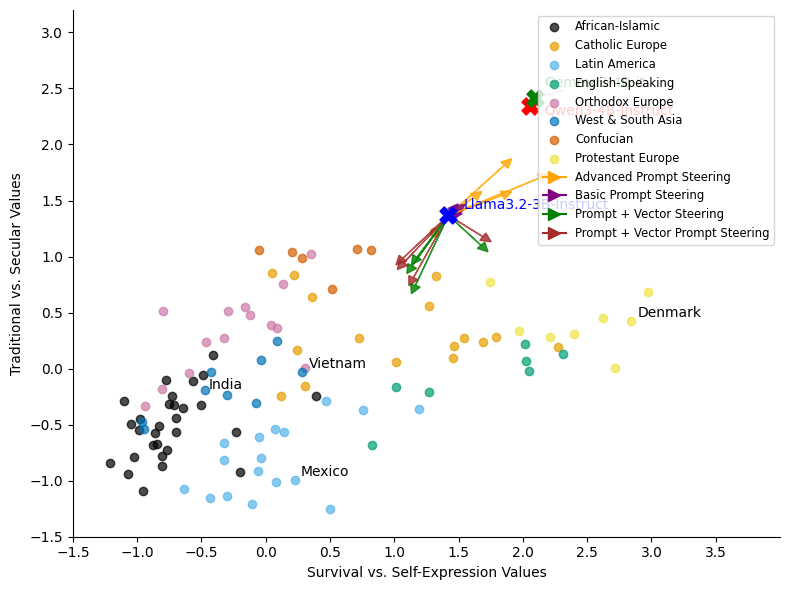

In [15]:
plot_culture_map(additional_points_df=probing_points_df, 
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df]),
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
				 additional_vectors_df=probing_llama_vector_df, 
     			# x_lim=(1, 3),
				# y_lim=(1, 3),
				#  title="LLMs Culture Value by Scenario-Based Probing on World culture map",
				 legend=True)

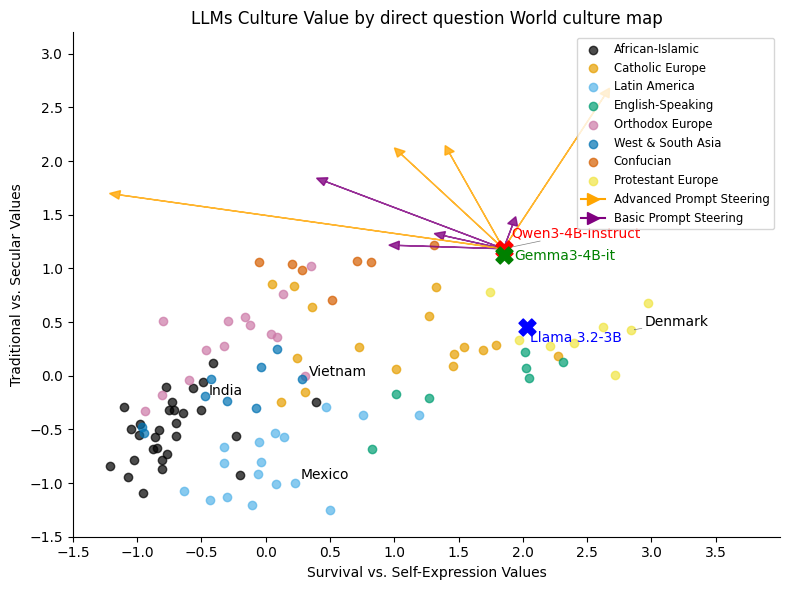

In [16]:
plot_culture_map(additional_points_df=direct_point_df, 
				additional_vectors_df=direct_qwen_vector_df, 
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df]),
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
				#  additional_vectors_df=probing_gemma_vector_df, 
     			# x_lim=(1, 3),
				# y_lim=(1, 3),
				 title="LLMs Culture Value by direct question World culture map",
				)

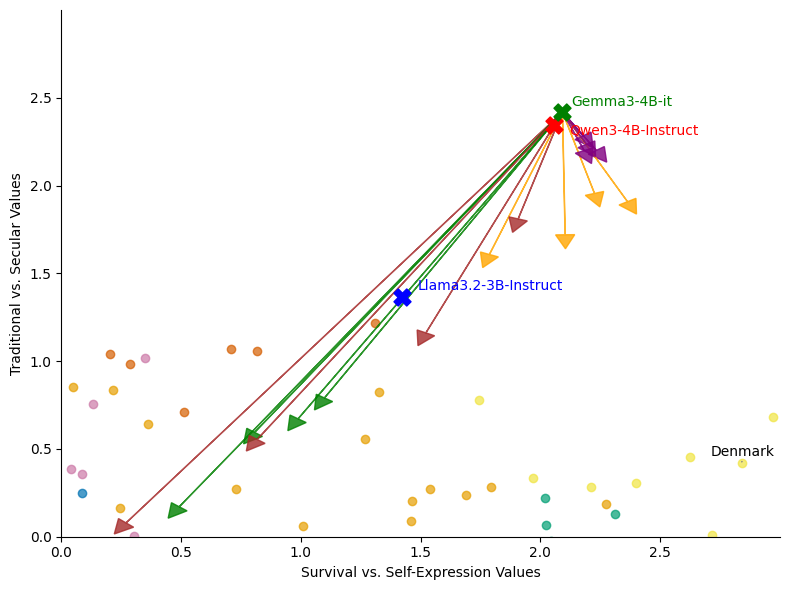

In [17]:
plot_culture_map(additional_points_df=probing_points_df, 
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df]),
				#  additional_vectors_df=pd.concat([probing_qwen_vector_df, probing_llama_vector_df, probing_gemma_vector_df]),
				 additional_vectors_df=probing_gemma_vector_df, 
     	x_lim=(0, 3),
				y_lim=(0, 3),
				#  title="LLMs Culture Value by Scenario-Based Probing on World culture map",
				 legend=False)

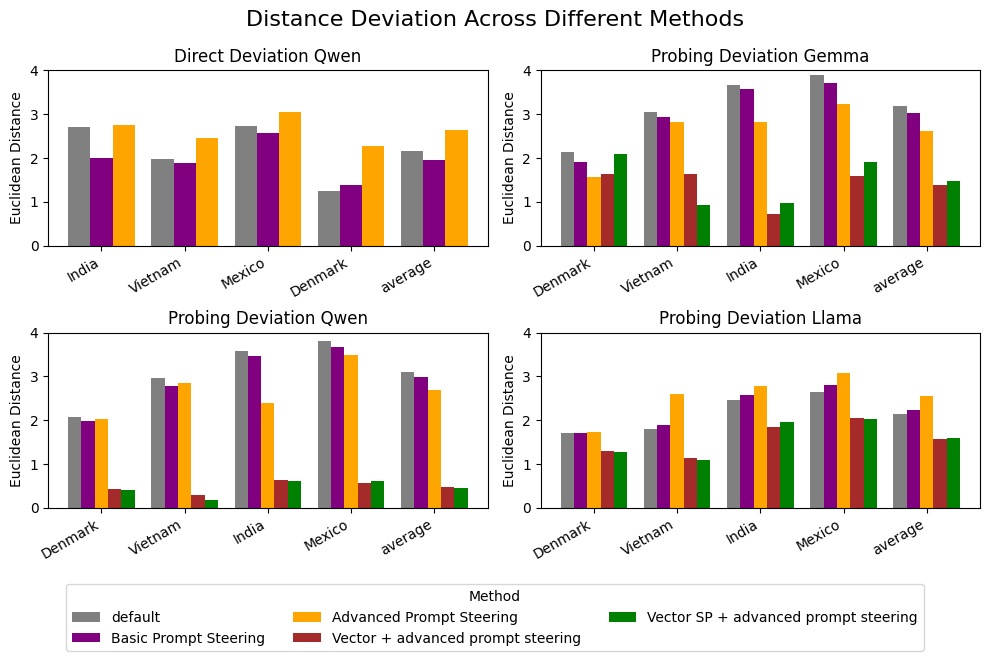

In [18]:

# --- Example of side-by-side usage ---
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

plot_distance_deviation(additional_points_df=direct_point_df, 
						additional_vectors_df=direct_qwen_vector_df, 
						ax=axs[0, 0], 
						title="Direct Deviation Qwen",
						legend=False)

plot_distance_deviation(additional_points_df=probing_points_df, 
						additional_vectors_df=probing_qwen_vector_df, 
						ax=axs[1, 0], 
						title="Probing Deviation Qwen",legend=False)

plot_distance_deviation(additional_points_df=probing_points_df, 
						additional_vectors_df=probing_llama_vector_df, 
						ax=axs[1, 1], 
						title="Probing Deviation Llama",legend=False)

plot_distance_deviation(additional_points_df=probing_points_df, 
						additional_vectors_df=probing_gemma_vector_df,
						ax=axs[0, 1], 
						title="Probing Deviation Gemma",legend=True)

# 3. Now extract the handles from that last plot
handles, labels = axs[0, 1].get_legend_handles_labels()

# 4. Remove the legend from that specific subplot so it's clean
axs[0, 1].get_legend().remove()

# 5. Create the global figure legend at the bottom
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.1), 
           ncol=3, 
           title='Method')
fig.suptitle('Distance Deviation Across Different Methods', fontsize=16)
plt.tight_layout()
# Adjust bottom manually if the legend still overlaps
plt.subplots_adjust(bottom=0.15) 
plt.show()

In [19]:
# load vector steering results
probing_qwen_steer_vector_df = pd.DataFrame()



tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_X_-0.2.json', model_name="X=-0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_Y_0.2.json', model_name="Y=0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_Y_-0.2.json', model_name="Y=-0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../qwen_steering_outputs_4/results_All_X_0.2.json', model_name="X=0.2")
probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../qwen_steering_outputs/results_All_X_-0.2_Y_-0.2.json', model_name="X=-0.2_Y=-0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)


# tmp = load_probing_profile_data('../outputs/qwen_steering_outputs/evaluation_results_X_0.2_Y_-0.2.json', model_name="X=0.2_Y=-0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../outputs/qwen_steering_outputs/evaluation_results_X_-0.2_Y_0.2.json', model_name="X=-0.2_Y=0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../qwen_steering_outputs/results_All_X_0.2_Y_0.2.json', model_name="X=0.2_Y=0.2")
# probing_qwen_steer_vector_df = pd.concat([probing_qwen_steer_vector_df, tmp], ignore_index=True)

probing_qwen_steer_vector_df['begin_point'] = "Qwen3-4B-Instruct"
probing_qwen_steer_vector_df['color'] = 'blue'
probing_qwen_steer_vector_df

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,source_file,begin_point,color
0,All,5.211374,8.128601,1.850874,9.198252,3.879732,2.999410,4.013614,3.527540,1.551351,2.625329,9.703245,2.660607,2.089439,2.797557,X=-0.2,../qwen_steering_outputs_4/results_All_X_-0.2....,Qwen3-4B-Instruct,blue
1,All,4.111465,7.995576,0.087635,7.016020,2.820037,2.638056,3.207647,2.583983,1.196955,1.822692,8.806973,1.627633,1.884324,1.091234,Y=0.2,../qwen_steering_outputs_4/results_All_Y_0.2.json,Qwen3-4B-Instruct,blue
2,All,5.170006,7.963185,1.852706,9.187920,3.846873,2.999345,4.040547,3.532578,1.598252,2.688237,9.698886,2.684782,2.068125,2.809742,Y=-0.2,../qwen_steering_outputs_4/results_All_Y_-0.2....,Qwen3-4B-Instruct,blue
3,All,3.932048,6.780083,0.313295,7.154155,2.776659,2.636049,3.375889,2.676577,1.294549,1.951598,9.063242,1.893478,2.036009,1.333694,X=0.2,../qwen_steering_outputs_4/results_All_X_0.2.json,Qwen3-4B-Instruct,blue


In [20]:
# load vector steering results
probing_llama_steer_vector_df = pd.DataFrame()


tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_-0.2.json', model_name="X=-0.2")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../llama_steering_outputs/results_All_Y_0.4.json', model_name="Y=0.4")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../llama_steering_outputs/results_All_Y_-0.2.json', model_name="Y=-0.2")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_0.4.json', model_name="X=0.4")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)


tmp = load_probing_profile_data('../llama_steering_outputs/results_All_Y_0.2.json', model_name="Y=0.2")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_0.2.json', model_name="X=0.2")
probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)


# tmp = load_probing_profile_data('../llama_steering_outputs/results_All_X_-0.2_Y_-0.2.json', model_name="X=-0.2_Y=-0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)


# tmp = load_probing_profile_data('../outputs/llama_steering_outputs/evaluation_results_X_0.2_Y_-0.2.json', model_name="X=0.2_Y=-0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)
# tmp = load_probing_profile_data('../outputs/qwen_steering_outputs/evaluation_results_X_-0.2_Y_0.2.json', model_name="X=-0.2_Y=0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../qwen_steering_outputs/results_All_X_0.2_Y_0.2.json', model_name="X=0.2_Y=0.2")
# probing_llama_steer_vector_df = pd.concat([probing_llama_steer_vector_df, tmp], ignore_index=True)

probing_llama_steer_vector_df['begin_point'] = "Llama3.2-3B-Instruct"
probing_llama_steer_vector_df['color'] = 'blue'
probing_llama_steer_vector_df

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,source_file,begin_point,color
0,All,3.773065,6.374543,0.786506,6.519450,2.792407,2.392421,3.221149,2.771712,1.511491,2.203410,7.424630,2.194499,1.483634,1.589485,X=-0.2,../llama_steering_outputs/results_All_X_-0.2.json,Llama3.2-3B-Instruct,blue
1,All,3.112191,5.623496,-0.093477,5.629225,2.377162,2.024550,2.699283,2.372074,1.453625,1.989584,5.790587,1.890544,1.057589,0.989423,Y=0.4,../llama_steering_outputs/results_All_Y_0.4.json,Llama3.2-3B-Instruct,blue
2,All,3.762222,6.232443,0.787103,6.600252,2.782467,2.408846,3.255885,2.771345,1.532741,2.242464,7.532554,2.200321,1.513640,1.609964,Y=-0.2,../llama_steering_outputs/results_All_Y_-0.2.json,Llama3.2-3B-Instruct,blue
3,All,3.017045,5.365591,-0.152091,5.487874,2.398464,1.985387,2.712307,2.377362,1.481365,2.033580,5.770617,1.898612,1.016367,1.017714,X=0.4,../llama_steering_outputs/results_All_X_0.4.json,Llama3.2-3B-Instruct,blue
4,All,3.258047,5.776544,0.061686,5.872881,2.433283,2.145841,2.848443,2.442486,1.448831,2.056221,6.356466,1.938212,1.212097,1.085032,Y=0.2,../llama_steering_outputs/results_All_Y_0.2.json,Llama3.2-3B-Instruct,blue
5,All,3.209925,5.590285,0.051662,5.840292,2.438914,2.128474,2.868363,2.449792,1.473849,2.081485,6.383311,1.953378,1.208761,1.111451,X=0.2,../llama_steering_outputs/results_All_X_0.2.json,Llama3.2-3B-Instruct,blue


In [21]:
# load vector steering results
probing_gemma_steer_vector_df = pd.DataFrame()


tmp = load_probing_profile_data('../gemma_steering_outputs/results_All_X_-0.2.json', model_name="X=-0.2")
probing_gemma_steer_vector_df = pd.concat([probing_gemma_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../gemma_steering_outputs/results_All_Y_-0.2.json', model_name="Y=-0.2")
probing_gemma_steer_vector_df = pd.concat([probing_gemma_steer_vector_df, tmp], ignore_index=True)

tmp = load_probing_profile_data('../gemma_steering_outputs/results_All_Y_0.2.json', model_name="Y=0.2")
probing_gemma_steer_vector_df = pd.concat([probing_gemma_steer_vector_df, tmp], ignore_index=True)
tmp = load_probing_profile_data('../gemma_steering_outputs/results_All_X_0.2.json', model_name="X=0.2")
probing_gemma_steer_vector_df = pd.concat([probing_gemma_steer_vector_df, tmp], ignore_index=True)

# tmp = load_probing_profile_data('../gemma_steering_outputs/results_All_Y_0.4.json', model_name="Y=0.4")
# probing_gemma_steer_vector_df = pd.concat([probing_gemma_steer_vector_df, tmp], ignore_index=True)
# tmp = load_probing_profile_data('../gemma_steering_outputs/results_All_X_0.4.json', model_name="X=0.4")
# probing_gemma_steer_vector_df = pd.concat([probing_gemma_steer_vector_df, tmp], ignore_index=True)


probing_gemma_steer_vector_df['begin_point'] = "Gemma3-4B-it"
probing_gemma_steer_vector_df['color'] = 'blue'
probing_gemma_steer_vector_df

,domain,X,F063,Y003,F120,G006,E018,Y,A008,A165,E025,F118,Y002,RC1,RC2,country,source_file,begin_point,color
0,All,5.286156,8.076926,1.972725,9.565929,3.878185,2.937018,4.018463,3.387962,1.635780,2.775950,9.970140,2.322480,2.098655,2.790610,X=-0.2,../gemma_steering_outputs/results_All_X_-0.2.json,Gemma3-4B-it,blue
1,All,5.221690,7.883484,1.980673,9.401765,3.909153,2.933376,4.081533,3.436501,1.700968,2.832574,9.972907,2.464714,2.065598,2.852131,Y=-0.2,../gemma_steering_outputs/results_All_Y_-0.2.json,Gemma3-4B-it,blue
2,All,3.459067,7.149327,-0.649257,6.226677,2.535648,2.032941,2.624149,2.276135,1.286331,1.681971,6.190850,1.685457,1.208508,0.647159,Y=0.2,../gemma_steering_outputs/results_All_Y_0.2.json,Gemma3-4B-it,blue
3,All,3.391909,6.374991,-0.391937,6.418684,2.521985,2.035822,2.804453,2.374174,1.380789,1.772280,6.674512,1.820507,1.380712,0.845008,X=0.2,../gemma_steering_outputs/results_All_X_0.2.json,Gemma3-4B-it,blue


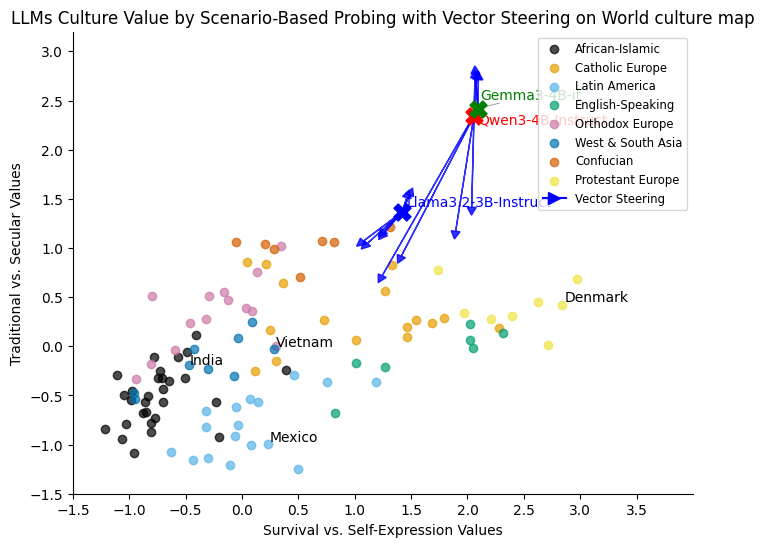

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_culture_map(
    		ax =ax,
      		additional_points_df=probing_points_df,\
			legend=True,
			title="LLMs Culture Value by Scenario-Based Probing with Vector Steering on World culture map",
    		# additional_vectors_df=pd.concat([probing_llama_steer_vector_df, probing_qwen_steer_vector_df]),
    		additional_vectors_df=pd.concat([probing_qwen_steer_vector_df, probing_llama_steer_vector_df, probing_gemma_steer_vector_df]),
			# x_lim=(0, 4.0),
			# y_lim=(0, 3.0),
    		# additional_vectors_df=probing_qwen_steer_vector_df,
      
      )



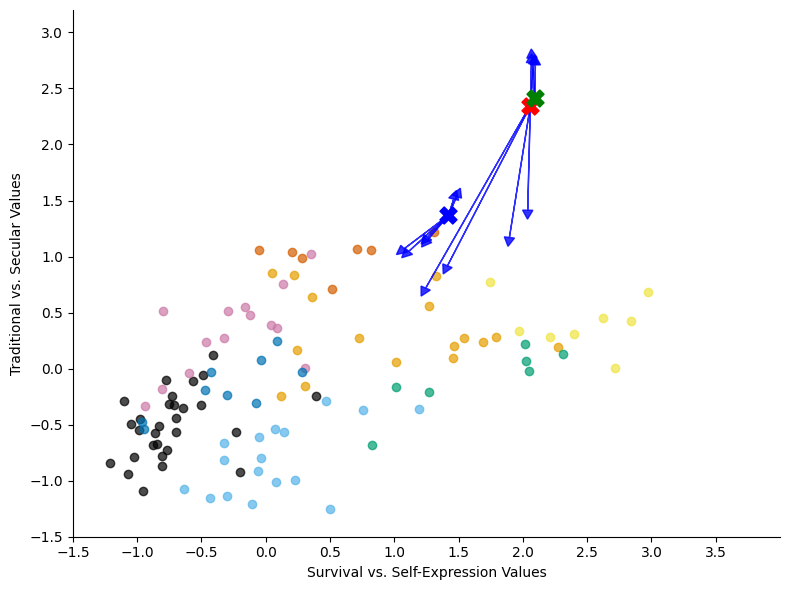

In [23]:
plot_culture_map(additional_points_df=probing_points_df,\
			legend=False,
			# title="LLMs Culture Value by Scenario-Based Probing with Vector Steering on World culture map",
    		# additional_vectors_df=pd.concat([probing_llama_steer_vector_df, probing_qwen_steer_vector_df]),
    		additional_vectors_df=pd.concat([probing_qwen_steer_vector_df, probing_llama_steer_vector_df, probing_gemma_steer_vector_df]),
			# x_lim=(0, 4.0),
			# y_lim=(0, 3.0),
    		# additional_vectors_df=probing_qwen_steer_vector_df,
			add_texts=False
      )

## Steering Trajectory Lines (Grid Coefficient Sweep)

Visualize how model responses move on the cultural map as the steering coefficient varies from -0.3 to +0.6, separately for X-axis (Survival↔Self-Expression) and Y-axis (Traditional↔Secular-Rational) steering.

In [24]:
import re

def load_grid_coeff_data(grid_dir, model_label):
	"""Load and parse outputs_grid_coeff summary_results.json for one model."""
	with open(f"{grid_dir}/summary_results.json") as f:
		summary = json.load(f)
	rows = []
	for pt in summary["points"]:
		label = pt["label"]
		if label == "Baseline":
			rows.append({"model": model_label, "axis": "Baseline", 'begin_point': model_label,
						 "coeff": 0.0, "RC1": pt["RC1"], "RC2": pt["RC2"],'source_file': f"{grid_dir}/details/baseline.json"})
		else:
			m = re.match(r"vector_steering_([-.\d]+)_([XY])", label)
			file_path = f"{grid_dir}/details/{label}_{pt['country']}.json"
			if m:
				coeff, axis = float(m.group(1)), m.group(2)
				rows.append({"model": model_label, "axis": axis, "begin_point": model_label,
							 "coeff": coeff, "RC1": pt["RC1"], "RC2": pt["RC2"],'source_file': file_path})
	return pd.DataFrame(rows)


In [25]:
GRID_DIR = "../outputs_grid_coeff"
model_configs = [
    ("Qwen_Qwen3-4B-Instruct-2507",      "Qwen3-4B-Instruct"),
    ("google_gemma-3-4b-it",              "Gemma3-4B-it"),
    ("meta-llama_Llama-3.2-3B-Instruct", "Llama3.2-3B-Instruct"),
]

grid_df = pd.concat([
    load_grid_coeff_data(f"{GRID_DIR}/{d}", label)
    for d, label in model_configs
], ignore_index=True)

# probing_points_df

In [26]:
def smooth_line(ax, x, y, color, marker, label, zorder=6, linewidth=2, markersize=6, linestyle='-'):
    """Plot a smooth spline through (x, y) points, with original markers on top."""
    from scipy.interpolate import make_interp_spline
    import numpy as np
    pts = np.array(list(zip(x, y)))
    # Parameterise by cumulative arc-length so the spline follows the actual path
    dists = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))])
    if len(dists) >= 4:
        t_fine = np.linspace(dists[0], dists[-1], 300)
        spl = make_interp_spline(dists, pts, k=3)
        smooth = spl(t_fine)
        ax.plot(smooth[:, 0], smooth[:, 1], color=color, linewidth=linewidth,
                linestyle=linestyle, zorder=zorder, label=label)
    else:
        ax.plot(x, y, color=color, linewidth=linewidth,
                linestyle=linestyle, zorder=zorder, label=label)
    # Scatter original data points on top
    ax.scatter(x, y, color=color, marker=marker, s=markersize**2,
               zorder=zorder+1, edgecolors='white', linewidths=0.5)



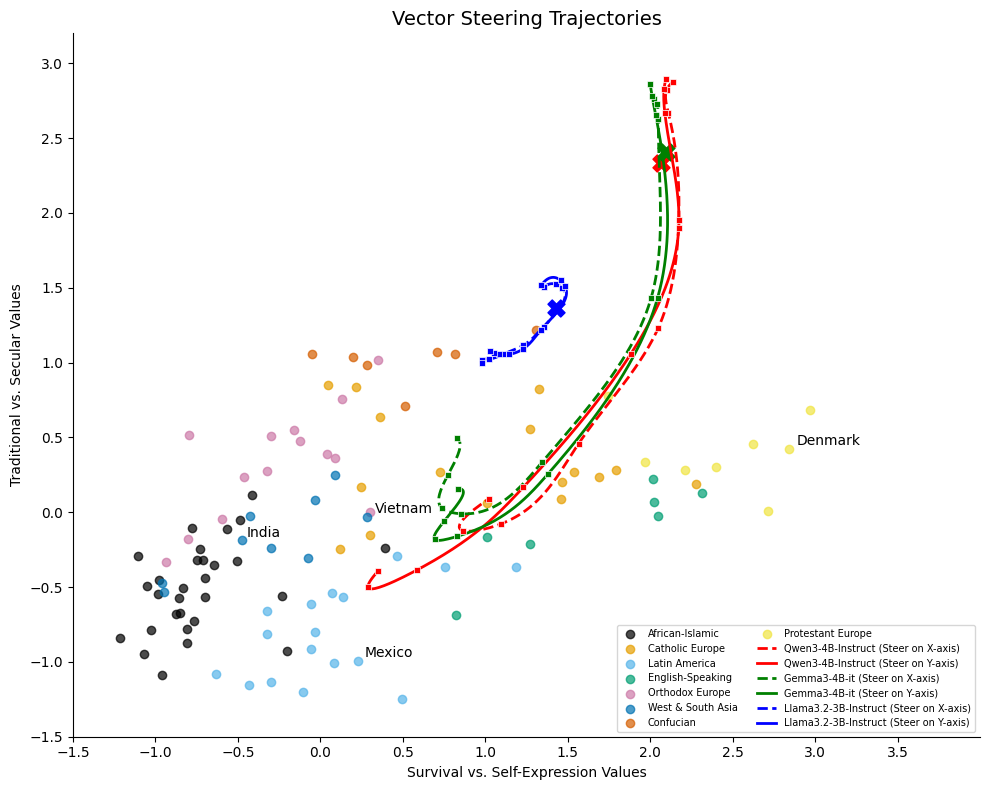

In [27]:
# Combined view: all models on one cultural map
from ultis import plot_culture_map

model_colors = {'Qwen3-4B-Instruct': 'red', 'Gemma3-4B-it': 'green', 'Llama3.2-3B-Instruct': 'blue'}

fig, ax = plt.subplots(figsize=(10, 8))
plot_culture_map(ax=ax, add_texts=True, legend=True)

for _, model_label in model_configs:
    color = model_colors[model_label]
    model_df = grid_df[grid_df['model'] == model_label]
    baseline = model_df[model_df['axis'] == 'Baseline']

    for axis_key, (marker, linestyle) in {'X': ('s', '--'), 'Y': ('s', '-')}.items():
        traj = model_df[model_df['axis'] == axis_key].sort_values('coeff')
        smooth_line(ax, traj['RC1'].values, traj['RC2'].values,
                    color=color, marker=marker, linestyle=linestyle,
                    label=f"{model_label} (Steer on {axis_key}-axis)",
                    linewidth=2, markersize=5)

    ax.scatter(baseline['RC1'], baseline['RC2'],
               marker='X', s=150, color=color, zorder=5)
            #    label=f"{model_label} Baseline")

ax.set_title('Vector Steering Trajectories', fontsize=14)
ax.legend(loc='lower right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('../outputs/steering_trajectories_combined.png', dpi=150, bbox_inches='tight')
plt.show()
